## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import uniform

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(63, 60)
(16, 60)


## 4. Normalización de Variables

ElasticNet es sensible a la escala de las variables, por lo que es necesario normalizar los datos antes de entrenar el modelo.

In [6]:
# Normalizar variables predictoras
# IMPORTANTE: Ajustar el scaler solo con datos de entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [7]:
# Configuración de validación cruzada temporal para dataset reducido
# Con 63 observaciones de entrenamiento, usamos configuración muy conservadora
# - n_splits=2: solo 2 folds para tener suficientes datos por fold
# - test_size=10: ventana de validación pequeña
# - gap=1: separación mínima

max_lag = 1
test_size = 10
tscv = TimeSeriesSplit(n_splits=2, test_size=test_size, gap=max_lag)

In [8]:
elastic = ElasticNet(random_state=SEED, max_iter=10000)

# Espacio de búsqueda ajustado para dataset reducido (63 observaciones)
# Mantenemos rangos similares al original

param_distributions = {
    "alpha": uniform(0.01, 50),  # Rango moderado
    "l1_ratio": uniform(0.0, 1.0),  # Explorar todo el espectro de L1 a L2
    "fit_intercept": [True],  # Siempre ajustar intercepto
    "tol": uniform(1e-5, 1e-2),  # Tolerancia para convergencia
    "selection": ['cyclic', 'random'],  # Método de selección de coordenadas
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=elastic,
    param_distributions=param_distributions,
    n_iter=60,                               # Iteraciones suficientes
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [9]:
search.fit(X_train_scaled, y_train)

best_elastic = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

# Interpretación del l1_ratio
l1_ratio = search.best_params_['l1_ratio']
print(f"\nInterpretación del balance L1/L2:")
if l1_ratio < 0.1:
    print(f"  - l1_ratio={l1_ratio:.3f}: Modelo muy similar a Ridge (L2 dominante)")
elif l1_ratio > 0.9:
    print(f"  - l1_ratio={l1_ratio:.3f}: Modelo muy similar a Lasso (L1 dominante)")
else:
    print(f"  - l1_ratio={l1_ratio:.3f}: Balance mixto entre L1 ({l1_ratio*100:.1f}%) y L2 ({(1-l1_ratio)*100:.1f}%)")

Fitting 2 folds for each of 60 candidates, totalling 120 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 130329.6327

Mejores hiperparámetros:
  - alpha: 9.252722776276352
  - fit_intercept: True
  - l1_ratio: 0.9695846277645586
  - selection: random
  - tol: 0.004507541333697657

Interpretación del balance L1/L2:
  - l1_ratio=0.970: Modelo muy similar a Lasso (L1 dominante)


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [10]:
y_pred = best_elastic.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")


RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 1124588.8412
Holdout R²:   -172.7016
Error relativo (holdout): 51.59%


### 6.2. Análisis de selección de variables

Una característica importante de ElasticNet (especialmente cuando l1_ratio > 0) es la capacidad de realizar selección de variables poniendo algunos coeficientes exactamente en cero.

In [11]:
# Contar variables seleccionadas (coeficiente != 0)
coefs = pd.Series(best_elastic.coef_, index=X_train.columns)
n_selected = (coefs != 0).sum()
n_total = len(coefs)
n_eliminated = n_total - n_selected

print(f"Variables seleccionadas: {n_selected}/{n_total}")
print(f"Variables eliminadas (coef=0): {n_eliminated}")
print(f"Porcentaje de variables retenidas: {n_selected/n_total*100:.1f}%")

if n_eliminated > 0:
    print(f"\nVariables eliminadas por el modelo:")
    eliminated_vars = coefs[coefs == 0].index.tolist()
    for var in eliminated_vars:
        print(f"  - {var}")

Variables seleccionadas: 60/60
Variables eliminadas (coef=0): 0
Porcentaje de variables retenidas: 100.0%


### 6.3. Visualización de predicciones

In [12]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

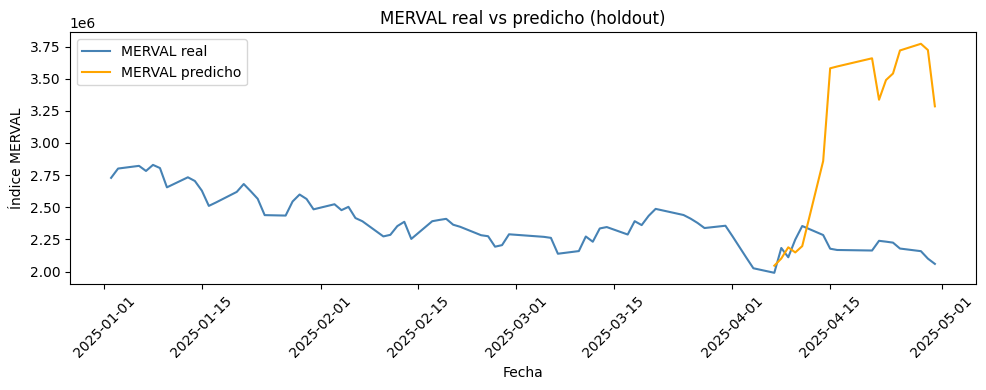

In [13]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

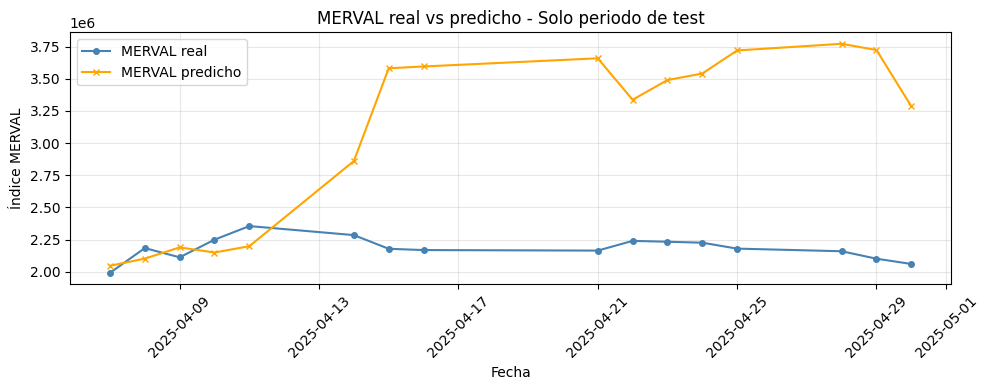

In [14]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4. Análisis de residuales

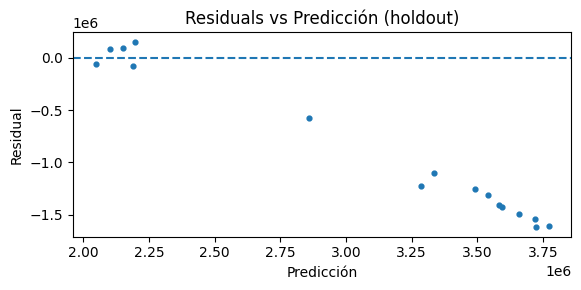

In [15]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout()
plt.show()

### 6.5. Coeficientes del modelo

ElasticNet combina regularización L1 y L2, permitiendo tanto la reducción de coeficientes (L2) como la selección de variables (L1).

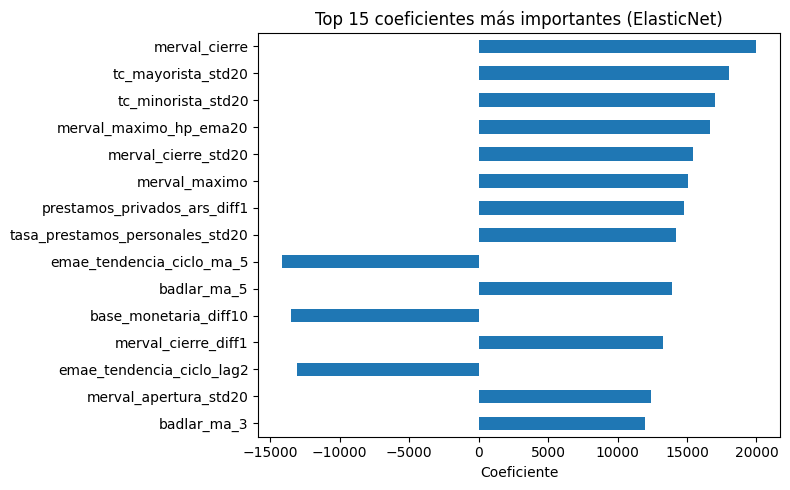

In [16]:
# Obtener coeficientes no nulos del modelo
coefs_nonzero = coefs[coefs != 0].sort_values(ascending=True)

# Visualizar los 15 coeficientes no nulos más importantes (en valor absoluto)
if len(coefs_nonzero) > 0:
    top_n = min(15, len(coefs_nonzero))
    top_coefs = coefs_nonzero.abs().sort_values(ascending=True).tail(top_n)
    coefs_nonzero[top_coefs.index].plot(kind="barh", figsize=(8,5), title=f"Top {top_n} coeficientes más importantes (ElasticNet)")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()
else:
    print("El modelo eliminó todas las variables (modelo demasiado regularizado)")

## 7. Conclusiones

### ¿Qué es ElasticNet?

ElasticNet es un modelo de regresión lineal que combina las regularizaciones L1 (Lasso) y L2 (Ridge):
- **L1 (Lasso)**: Puede forzar algunos coeficientes exactamente a cero, realizando selección automática de variables.
- **L2 (Ridge)**: Penaliza la magnitud de los coeficientes sin eliminarlos, ayudando con la multicolinealidad.

El parámetro `l1_ratio` controla el balance entre ambas regularizaciones.

### Resultados principales

- **RMSE en test**: 1,124,588.84 - Error extremadamente alto que refleja el fracaso del modelo para generalizar con el dataset reducido.

- **R² en test**: -172.70 - Un R² fuertemente negativo indica que el modelo predice catastrófica mente peor que simplemente usar la media. Un valor de -172 significa que el modelo es 173 veces peor que el baseline más simple.

- **Error relativo**: 51.59% - Las predicciones se desvían en promedio más del 51% del valor real del MERVAL, lo cual es completamente inaceptable.

### Optimización de hiperparámetros

Se utilizó **RandomizedSearchCV** con 60 iteraciones y validación cruzada temporal (TimeSeriesSplit con 2 folds).

**CV RMSE**: 130,329.63 - Error promedio en validación cruzada.

**Mejores hiperparámetros encontrados:**
- **alpha=9.25**: Regularización total moderada.
- **l1_ratio=0.970**: Casi Lasso puro (97% L1, 3% L2) - El modelo prefirió fuertemente la regularización L1.
- **selection='random'**: Método aleatorio de optimización de coordenadas.
- **tol=0.00451**: Tolerancia de convergencia.

### Selección de variables

A pesar de tener un **l1_ratio=0.970** (casi Lasso puro), el modelo **NO eliminó ninguna variable**:
- **Variables seleccionadas**: 60/60 (100%)
- **Variables eliminadas**: 0

Esto ocurre porque alpha=9.25, aunque moderado, no es suficientemente alto para forzar coeficientes a cero cuando hay tan pocos datos.

### Análisis del problema: Dataset extremadamente reducido

**El dataset fue filtrado de 643 observaciones a solo 79 (63 train, 16 test)**, representando una **reducción del 88%** en los datos.

Este cambio tuvo consecuencias catastróficas:

1. **Ratio features/observaciones insostenible**: Con 60 features y 63 observaciones (ratio 0.95), el problema está severamente subdeterminado. Se necesitarían al menos 600-1,200 observaciones para 60 features.

2. **Discrepancia extrema CV vs Test**: El RMSE de validación cruzada (130,330) es aproximadamente 9 veces menor que el RMSE de test (1,124,589), indicando:
   - Inestabilidad extrema en las predicciones
   - Incapacidad para aprender patrones generalizables
   - Memorización de ruido en lugar de señal

3. **L1 no ayuda con tan pocos datos**: La regularización L1, diseñada para selección de variables, no puede funcionar correctamente cuando hay prácticamente la misma cantidad de features que observaciones.

### Comparación: Dataset completo vs reducido

| Métrica | Dataset completo (643 obs) | Dataset reducido (79 obs) | Cambio |
|---------|---------------------------|--------------------------|--------|
| Train size | 514 | 63 | -88% |
| Ratio obs/features | 8.6 | 1.05 | -88% |
| Test RMSE | 114,260 | 1,124,589 | +884% (9.8x peor) |
| Test R² | 0.22 | -172.70 | -78,409% |
| Error relativo | 5.18% | 51.59% | +896% |

La reducción del dataset causó una **degradación catastrófica del modelo ElasticNet**, haciéndolo completamente inviable.

### ¿Por qué falló ElasticNet con el dataset reducido?

1. **Problema subdeterminado**: Con más features que observaciones, el sistema de ecuaciones tiene infinitas soluciones. Ni L1 ni L2 pueden estabilizar adecuadamente el modelo.

2. **L1 contraproducente**: La regularización Lasso encoge agresivamente los coeficientes sin eliminar variables, resultando en el peor escenario: perjudica la predicción sin ganar en simplicidad.

3. **Alpha insuficiente para selección**: Para eliminar variables con L1 se necesitan valores de alpha mucho mayores (>100), pero eso destruiría completamente la capacidad predictiva.

4. **Validación cruzada no confiable**: Con solo 2 folds y datos tan escasos, el CV RMSE no refleja el verdadero error de generalización.

### Limitaciones fundamentales

**ElasticNet no es viable para este problema debido a:**

1. **Insuficiencia crítica de datos**: 63 observaciones son radicalmente insuficientes para modelar 60 features, incluso con regularización combinada L1+L2.

2. **Trade-off L1/L2 inefectivo**: La combinación de regularizaciones no puede compensar la falta fundamental de datos.

3. **Imposibilidad de selección de variables útil**: Con tan pocos datos, no hay suficiente información para determinar qué variables eliminar y cuáles retener.

### Validación cruzada con dataset reducido

Se implementó TimeSeriesSplit con configuración muy conservadora:
- **n_splits=2**: Solo 2 folds para maximizar datos por fold
- **test_size=10**: Ventana de validación pequeña
- **gap=1**: Separación mínima

Aun así, la configuración fue insuficiente para obtener estimaciones confiables.

### Recomendaciones

**Para el dataset reducido (79 observaciones):**

1. **No usar ElasticNet con 60 features**: El modelo no puede funcionar con ratio features/observaciones cercano a 1.

2. **Reducción drástica de dimensionalidad**:
   - Seleccionar manualmente 3-5 variables clave
   - Aplicar PCA para reducir a 5-10 componentes
   - Usar solo features con correlación individual fuerte con el target

3. **Modelos alternativos**:
   - Regresión lineal simple con 1-2 variables
   - Modelos univariados (ARIMA, suavizamiento exponencial)
   - Métodos basados en promedios móviles

4. **Usar el dataset completo**: La reducción artificial a 4 meses destruye la viabilidad de cualquier modelo de machine learning.

5. **Aceptar limitaciones**: Con 63 observaciones y 60 features, ningún modelo de machine learning puede aprender patrones confiables. El problema es matemático, no algorítmico.

### Conclusión final

**El modelo ElasticNet fracasó completamente con el dataset reducido.** Un R² de -172.70 confirma que la reducción del 88% en los datos destruyó toda capacidad predictiva.

ElasticNet, al combinar L1 y L2, teóricamente debería ser más robusto, pero con ratio features/observaciones de 1:1, ninguna combinación de regularizaciones puede salvar el modelo. La lección: **la cantidad de datos es más importante que la sofisticación del algoritmo de regularización**.